# Exploring annotation dataset
This notebook provides a demonstration for loading, exploring, and visualizing the "Citizen science annotations of wandering albatrosses in satellite imagery" dataset. It serves as a companion to the data paper, demonstrating the .json file structure and how it can be accessed with python.

#### --- 1. Setting up the Environment ---

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt  
import numpy as np
import os
from PIL import Image
import matplotlib.cm as cm

print("Libraries imported successfully.")

Libraries imported successfully.


#### --- 2. Understanding the Data Format ---

The annotation data is stored in a single JSON file (`citizen_science_annotations.json`).
This format follows a common structure for machine readable image annotation datasets.

The JSON file has three main sections:

1.  **`dataset_info`**: Contains general information about the dataset, including it's name, authors,
    description, and creation date. 

2.  **`images`**: This is a list of dictionaries, where each dictionary represents a single image.
    Each image entry includes:
    * `img_id`: A unique identifier for the image.
    * `file_name`: The relative path to the image file (e.g., "1_albatross_1_...png").
    * `width`, `height`: Dimensions of the image.
    * `metadata`: A nested dictionary containing image-specific metadata (e.g., satellite image acquisition date,
        sensor, cloud cover, site name, number of reviewers). This metadata can be useful for determining image location, quality, and assigning data splits.
    * `annotations`: A list of dictionaries, where each dictionary represents a single point annotation.
        * For images with **Albatross Present**, this list contains entries like `{"user_id": ..., "x": ..., "y": ..., "class_name": "albatross"}`.
        * The `"user_id"` is unique to each citizen scientist. Each image was reviewed by seven people, so contains multiple annotations per feature. 
        * For images categorised as **No Albatross Present** or **Poor Image**, this list is **empty (`[]`)**. 
3.  **`categories`**: This section lists the classes of objects annotated in the dataset. In this specific dataset we only have one class, albatross, 
so it is structured as `[{"id": 1, "name": "albatross"}]`.


#### --- 3. Loading the Annotation Data ---

In [2]:
# Define the path to your JSON annotation file, e.g.
json_file_path = 'data/wandering_albatross_annotations/citizen_science_annotations.json'

try:
    with open(json_file_path, 'r') as f:
        data = json.load(f)
    print(f"Successfully loaded data from {json_file_path}")
except FileNotFoundError:
    print(f"Error: {json_file_path} not found. Please ensure the JSON file is in the correct directory.")
    exit()

# Extract dataset information
dataset_info = data['dataset_info']
print("\n--- Dataset Information ---")
for key, value in dataset_info.items():
    print(f"- {key.replace('_', ' ').title()}: {value}")

# Extract categories (in this case, just 'albatross')
categories = data['categories']
print(f"\n--- Categories: {categories} ---")

Successfully loaded data from data/wandering_albatross_annotations/citizen_science_annotations.json

--- Dataset Information ---
- Name: Citizen science annotations of wandering albatrosses in satellite imagery, a dataset for training machine learning models
- Authors: Ellen Bowler, Marie R. G. Attard, Richard A. Phillips, Peter T. Fretwell
- Doi: placeholder
- Description: Citizen science point annotations of wandering albatrosses in MAXAR WorldView-3 satellite imagery over South Georgia, with associated metadata
- Version: 1.0
- Source: MAXAR WorldView-3
- Date Created: 2025-07-11

--- Categories: [{'id': 1, 'name': 'albatross'}] ---


#### --- 4. Exploring the Data with Pandas ---

In [3]:
# Convert the 'images' list from the JSON into a Pandas DataFrame for exploration
images_df = pd.DataFrame(data['images'])

print("\n--- Images DataFrame Overview (first 5 rows) ---")
print(images_df.head())

print("\n--- Images DataFrame Info ---")
images_df.info()

# Flatten the annotations into a separate DataFrame for easier analysis of individual points
all_annotations = []
for img_entry in data['images']:
    img_id = img_entry['img_id']
    for ann in img_entry['annotations']:
        # Create a dictionary for each annotation, including the parent image_id
        annotation_record = {
            'img_id': img_id,
            'user_id': ann['user_id'],
            'x': ann['x'],
            'y': ann['y'],
            'class_name': ann['class_name']
        }
        all_annotations.append(annotation_record)

annotations_df = pd.DataFrame(all_annotations)

print("\n--- Annotations DataFrame Overview (first 5 rows) ---")
if not annotations_df.empty:
    print(annotations_df.head())
    print("\n--- Annotations DataFrame Info ---")
    annotations_df.info()
else:
    print("No annotations found in the dataset to display in DataFrame.")



--- Images DataFrame Overview (first 5 rows) ---
                           img_id                           file_name  width  \
0  1_albatross_1_1040010006129600  1_albatross_1_1040010006129600.png    700   
1  2_albatross_1_1040010006129600  2_albatross_1_1040010006129600.png    700   
2  3_albatross_1_1040010006129600  3_albatross_1_1040010006129600.png    700   
3  4_albatross_1_1040010006129600  4_albatross_1_1040010006129600.png    700   
4  5_albatross_1_1040010006129600  5_albatross_1_1040010006129600.png    700   

   height                                           metadata annotations  
0     700  {'acquisition_date': '2015-01-24T12:30:28.1809...          []  
1     700  {'acquisition_date': '2015-01-24T12:30:28.1809...          []  
2     700  {'acquisition_date': '2015-01-24T12:30:28.1809...          []  
3     700  {'acquisition_date': '2015-01-24T12:30:28.1809...          []  
4     700  {'acquisition_date': '2015-01-24T12:30:28.1809...          []  

--- Images DataFra

In [4]:
# --- Basic Data Statistics ---
print("\n--- Dataset Statistics ---")
total_images = len(images_df)
print(f"Total number of images: {total_images}")

images_with_annotations = images_df[images_df['annotations'].apply(len) > 0]
num_images_with_annotations = len(images_with_annotations)
print(f"Number of images with at least one annotation: {num_images_with_annotations}")

images_without_annotations = images_df[images_df['annotations'].apply(len) == 0]
num_images_without_annotations = len(images_without_annotations)
print(f"Number of images with no annotations (explicitly marked): {num_images_without_annotations}")

total_annotations = len(annotations_df) if not annotations_df.empty else 0
print(f"Total number of individual point annotations: {total_annotations}")

if not annotations_df.empty:
    unique_annotators = annotations_df['user_id'].nunique()
    print(f"Number of unique citizen science annotators: {unique_annotators}")

    # Display counts per annotator
    print("\nAnnotations per User ID:")
    user_counts = annotations_df['user_id'].value_counts().reset_index()
    user_counts.columns = ['User ID', 'Annotation Count']
    print(user_counts) 



--- Dataset Statistics ---
Total number of images: 10833
Number of images with at least one annotation: 4294
Number of images with no annotations (explicitly marked): 6539
Total number of individual point annotations: 65988
Number of unique citizen science annotators: 363

Annotations per User ID:
     User ID  Annotation Count
0       4293              9977
1          6              4693
2       4552              3536
3       3974              3002
4       4364              2763
..       ...               ...
358     4433                 1
359     3954                 1
360     4620                 1
361     4875                 1
362     3795                 1

[363 rows x 2 columns]


In [5]:
# --- Explore Image Metadata ---

# To access metadata fields, we first need to normalize the 'metadata' column
# This converts the nested 'metadata' dictionary into separate columns in a new DataFrame
metadata_df = pd.json_normalize(images_df['metadata'])
# Concatenate original image_id and file_name for referencing
metadata_df = pd.concat([images_df[['img_id', 'file_name']], metadata_df], axis=1)

print("\nMetadata DataFrame Overview (first 5 rows):")
print(metadata_df.head())

# How many unique satellite catalog IDs are there?
if 'catalogue_id' in metadata_df.columns:   
    unique_satellite_ids = metadata_df['catalogue_id'].unique()
    num_unique_satellite_ids = len(unique_satellite_ids)
    print(f"\nNumber of unique satellite catalog IDs: {num_unique_satellite_ids}")
    print(f"Unique satellite catalog IDs: {unique_satellite_ids}") 
else:
    print("\n'catalogue_id' column not found in metadata.")

# How many unique site_name locations are there?
if 'site_name' in metadata_df.columns:
    unique_site_names = metadata_df['site_name'].unique()
    num_unique_site_names = len(unique_site_names)
    print(f"\nNumber of unique 'site_name' locations: {num_unique_site_names}")
    print(f"Unique 'site_name' locations: {unique_site_names}")
else:
    print("\n'site_name' column not found in metadata.")


# How many images are classified as poor by all 7 people?
if 'num_poor_image' in metadata_df.columns and 'num_reviewers' in metadata_df.columns:
    images_poor_by_all = metadata_df[metadata_df['num_poor_image'] == metadata_df['num_reviewers']]
    num_images_poor_by_all = len(images_poor_by_all)
    print(f"\nNumber of images classified as 'poor' by all reviewers: {num_images_poor_by_all}")
    if num_images_poor_by_all > 0:
        print("Image IDs classified as 'poor' by all reviewers:")
        print(images_poor_by_all['img_id'].tolist())
else:
    print("\n'num_poor_image' or 'num_reviewers' columns not found in metadata for this analysis.")



Metadata DataFrame Overview (first 5 rows):
                           img_id                           file_name  \
0  1_albatross_1_1040010006129600  1_albatross_1_1040010006129600.png   
1  2_albatross_1_1040010006129600  2_albatross_1_1040010006129600.png   
2  3_albatross_1_1040010006129600  3_albatross_1_1040010006129600.png   
3  4_albatross_1_1040010006129600  4_albatross_1_1040010006129600.png   
4  5_albatross_1_1040010006129600  5_albatross_1_1040010006129600.png   

              acquisition_date  off_nadir_angle        sensor  target_azimuth  \
0  2015-01-24T12:30:28.180989Z        26.685778  worldview-03      110.845413   
1  2015-01-24T12:30:28.180989Z        26.685778  worldview-03      110.845413   
2  2015-01-24T12:30:28.180989Z        26.685778  worldview-03      110.845413   
3  2015-01-24T12:30:28.180989Z        26.685778  worldview-03      110.845413   
4  2015-01-24T12:30:28.180989Z        26.685778  worldview-03      110.845413   

   cloud_cover_percentage    

#### --- 5. Visualizing Annotations ---

In [39]:
def plot_annotations_on_image(image_entry, image_root_path=".", save_plot=False, output_dir="example_annotation_plots", empty_image_text="No Albatross Present"):
    """
    Loads an image and plots the associated annotations.
    
    Args:
        image_entry (dict): A dictionary representing a single image from the JSON 'images' list.
        image_root_path (str): The root directory where image files are stored (for real images).
    """
    img_id = image_entry['img_id']
    file_name = image_entry['file_name']
    width = image_entry['width']
    height = image_entry['height']
    annotations = image_entry['annotations']
    
    print(f"\n--- Visualizing Image: {img_id} ({file_name}) ---")
    print(f"Image dimensions: {width}x{height} pixels")
    print(f"Number of annotations: {len(annotations)}")

    try:
        img_path = os.path.join(image_root_path, img_id + ".png") 
        img = Image.open(img_path)
    except FileNotFoundError:
        print(f"Warning: Image file not found at {img_path}. Using placeholder.")
    
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    
    # Plot annotations if any exist
    if annotations:
        # Extract unique user IDs to assign unique colors
        unique_user_ids = sorted(list(set([ann['user_id'] for ann in annotations])))
        
        # colors = cm.get_cmap("Accent", len(unique_user_ids))
        colors = cm.get_cmap("Set1", len(unique_user_ids))

        # Map user IDs to colors
        user_id_to_color = {user_id: colors(i) for i, user_id in enumerate(unique_user_ids)}

        # Plot each user's annotations separately to create a proper legend
        for user_id in unique_user_ids:
            user_annotations = [ann for ann in annotations if ann['user_id'] == user_id]
            if user_annotations:
                x_coords = [ann['x'] for ann in user_annotations]
                y_coords = [ann['y'] for ann in user_annotations]
                
                plt.scatter(
                    x_coords, y_coords,
                    marker='o',
                    facecolors = 'none',
                    s=250,
                    edgecolors=user_id_to_color[user_id],
                    linewidth=2,
                    label=f'User {user_id} ({len(user_annotations)} points)'
                )        
        plt.legend(title="Annotators", bbox_to_anchor=(1.05, 1), loc='upper left', title_fontsize=14, fontsize=12) # Place legend outside plot
    else:
        plt.text(width / 2, height / 2, empty_image_text,
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=20, color='gray', bbox=dict(facecolor='white', alpha=0.7))
        
    plt.title(f"Annotations for Image: {img_id}", fontsize=14)
    plt.xlabel("X Coordinate (pixels)", fontsize=12)
    plt.ylabel("Y Coordinate (pixels)", fontsize=12)
    plt.xlim(0, width)
    plt.ylim(height, 0) # Invert Y-axis for image coordinates (origin top-left)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    if save_plot:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        output_path = os.path.join(output_dir, f"{img_id}_annotations.png")
        plt.savefig(output_path, bbox_inches='tight')
        print(f"Plot saved to {output_path}")
        
    plt.show()
    plt.close()


--- Visualizing Image: 7537_albatross_64_1040010056021B00 (7537_albatross_64_1040010056021B00.tif) ---
Image dimensions: 700x700 pixels
Number of annotations: 15
Plot saved to example_annotation_plots\7537_albatross_64_1040010056021B00_annotations.png


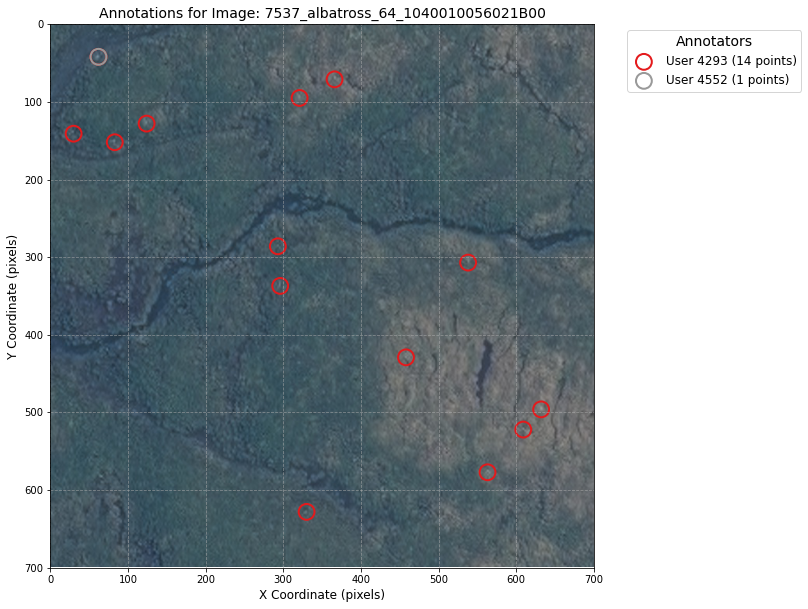


--- Visualizing Image: 11488_albatross_61_1040010047374200 (11488_albatross_61_1040010047374200.tif) ---
Image dimensions: 700x700 pixels
Number of annotations: 0
Plot saved to example_annotation_plots\11488_albatross_61_1040010047374200_annotations.png


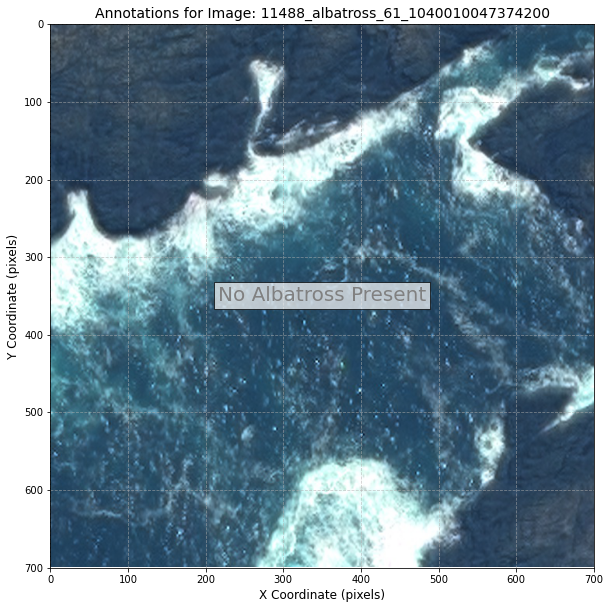


--- Visualizing Image: 5013_albatross_72_10400100655C5200 (5013_albatross_72_10400100655C5200.tif) ---
Image dimensions: 700x700 pixels
Number of annotations: 0
Plot saved to example_annotation_plots\5013_albatross_72_10400100655C5200_annotations.png


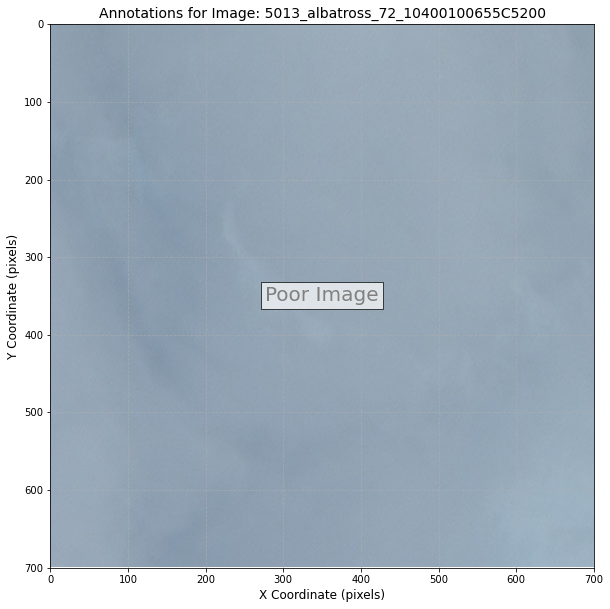

In [ ]:
# Set path to image folder, e.g
image_folder = "data/wandering_albatross_images/"  # Adjust this path as needed

# --- Example 1: Plotting an image with annotations ---
# Find the first image that has annotations
image_with_anns = images_df[images_df['annotations'].apply(len) > 10].sample(n=1).iloc[0]
plot_annotations_on_image(image_with_anns, image_folder, save_plot=True)

# --- Example 2: Plotting an image with NO annotations ---
# Find example image which was marked as having no albatross by all observers
image_without_anns = images_df[images_df['metadata'].apply(lambda m: m.get('num_no_feature_present') == 7)].sample(n=1).iloc[0]
plot_annotations_on_image(image_without_anns, image_folder, save_plot=True, empty_image_text="No Albatross Present")

# --- Example 3: Plotting an image classified as 'poor' by all reviewers ---
# Get the first image entry that was classified as poor by all reviewers
poor_image_entry = images_df[images_df['metadata'].apply(lambda m: m.get('num_poor_image') == 7)].sample(n=1).iloc[0]
plot_annotations_on_image(poor_image_entry, image_folder, save_plot=True, empty_image_text="Poor Image")

#### --- 6. Load expert annotations ---

In [ ]:
# Define the path to your expert JSON annotation file, e.g.
json_file_path = 'data/wandering_albatross_annotations/expert_annotations.json'

try:
    with open(json_file_path, 'r') as f:
        data = json.load(f)
    print(f"Successfully loaded data from {json_file_path}")
except FileNotFoundError:
    print(f"Error: {json_file_path} not found. Please ensure the JSON file is in the correct directory.")
    exit()

# Extract dataset information
dataset_info = data['dataset_info']
print("\n--- Dataset Information ---")
for key, value in dataset_info.items():
    print(f"- {key.replace('_', ' ').title()}: {value}")

# Extract categories (in this case, just 'albatross')
categories = data['categories']
print(f"\n--- Categories: {categories} ---")

Successfully loaded data from annotations/expert_annotations.json

--- Dataset Information ---
- Name: Expert annotations of wandering albatrosses in satellite imagery, a dataset for validating results
- Authors: Ellen Bowler, Marie R. G. Attard, Richard A. Phillips, Peter T. Fretwell
- Doi: placeholder
- Description: Expert point annotations of wandering albatrosses at four breeding sites, captured in MAXAR WorldView-3 satellite imagery, with associated metadata
- Version: 1.0
- Source: MAXAR WorldView-3
- Date Created: 2025-07-11

--- Categories: [{'id': 1, 'name': 'albatross'}] ---


In [52]:
# Convert the 'images' list from the JSON into a Pandas DataFrame for exploration
images_df = pd.DataFrame(data['images'])

print("\n--- Images DataFrame Overview (first 5 rows) ---")
print(images_df.head())

print("\n--- Images DataFrame Info ---")
images_df.info()

# Flatten the annotations into a separate DataFrame for easier analysis of individual points
all_annotations = []
for img_entry in data['images']:
    img_id = img_entry['img_id']
    for ann in img_entry['annotations']:
        # Create a dictionary for each annotation, including the parent image_id
        annotation_record = {
            'img_id': img_id,
            'user_id': ann['user_id'],
            'x': ann['x'],
            'y': ann['y'],
            'class_name': ann['class_name']
        }
        all_annotations.append(annotation_record)

annotations_df = pd.DataFrame(all_annotations)

print("\n--- Annotations DataFrame Overview (first 5 rows) ---")
if not annotations_df.empty:
    print(annotations_df.head())
    print("\n--- Annotations DataFrame Info ---")
    annotations_df.info()
else:
    print("No annotations found in the dataset to display in DataFrame.")


--- Images DataFrame Overview (first 5 rows) ---
                              img_id                              file_name  \
0  481_albatross_45_1040010029A1D400  481_albatross_45_1040010029A1D400.png   
1  482_albatross_45_1040010029A1D400  482_albatross_45_1040010029A1D400.png   
2  483_albatross_45_1040010029A1D400  483_albatross_45_1040010029A1D400.png   
3  484_albatross_45_1040010029A1D400  484_albatross_45_1040010029A1D400.png   
4  485_albatross_45_1040010029A1D400  485_albatross_45_1040010029A1D400.png   

   width  height                                           metadata  \
0    700     700  {'acquisition_date': '2017-02-03T12:44:40.3754...   
1    700     700  {'acquisition_date': '2017-02-03T12:44:40.3754...   
2    700     700  {'acquisition_date': '2017-02-03T12:44:40.3754...   
3    700     700  {'acquisition_date': '2017-02-03T12:44:40.3754...   
4    700     700  {'acquisition_date': '2017-02-03T12:44:40.3754...   

  annotations  
0          []  
1          []  


In [54]:
# --- Basic Data Statistics ---
print("\n--- Dataset Statistics ---")
total_images = len(images_df)
print(f"Total number of images: {total_images}")

images_with_annotations = images_df[images_df['annotations'].apply(len) > 0]
num_images_with_annotations = len(images_with_annotations)
print(f"Number of images with at least one annotation: {num_images_with_annotations}")

images_without_annotations = images_df[images_df['annotations'].apply(len) == 0]
num_images_without_annotations = len(images_without_annotations)
print(f"Number of images with no annotations (explicitly marked): {num_images_without_annotations}")

total_annotations = len(annotations_df) if not annotations_df.empty else 0
print(f"Total number of individual point annotations: {total_annotations}")

if not annotations_df.empty:
    unique_annotators = annotations_df['user_id'].nunique()
    print(f"Number of unique expert annotators: {unique_annotators}")

    # Display counts per annotator
    print("\nAnnotations per User ID:")
    user_counts = annotations_df['user_id'].value_counts().reset_index()
    user_counts.columns = ['User ID', 'Annotation Count']
    print(user_counts) 



--- Dataset Statistics ---
Total number of images: 542
Number of images with at least one annotation: 231
Number of images with no annotations (explicitly marked): 311
Total number of individual point annotations: 7244
Number of unique expert annotators: 7

Annotations per User ID:
   User ID  Annotation Count
0     3544              1401
1     4033              1236
2     3543              1102
3     6850               985
4     6851               959
5     7187               937
6     6852               624


In [55]:
# --- Explore Image Metadata ---

# To access metadata fields, we first need to normalize the 'metadata' column
# This converts the nested 'metadata' dictionary into separate columns in a new DataFrame
metadata_df = pd.json_normalize(images_df['metadata'])
# Concatenate original image_id and file_name for referencing
metadata_df = pd.concat([images_df[['img_id', 'file_name']], metadata_df], axis=1)

print("\nMetadata DataFrame Overview (first 5 rows):")
print(metadata_df.head())

# How many unique satellite catalog IDs are there?
if 'catalogue_id' in metadata_df.columns:   
    unique_satellite_ids = metadata_df['catalogue_id'].unique()
    num_unique_satellite_ids = len(unique_satellite_ids)
    print(f"\nNumber of unique satellite catalog IDs: {num_unique_satellite_ids}")
    print(f"Unique satellite catalog IDs: {unique_satellite_ids}") 
else:
    print("\n'catalogue_id' column not found in metadata.")

# How many unique site_name locations are there?
if 'site_name' in metadata_df.columns:
    unique_site_names = metadata_df['site_name'].unique()
    num_unique_site_names = len(unique_site_names)
    print(f"\nNumber of unique 'site_name' locations: {num_unique_site_names}")
    print(f"Unique 'site_name' locations: {unique_site_names}")
else:
    print("\n'site_name' column not found in metadata.")


# How many images are classified as poor by all 7 people?
if 'num_poor_image' in metadata_df.columns and 'num_reviewers' in metadata_df.columns:
    images_poor_by_all = metadata_df[metadata_df['num_poor_image'] == metadata_df['num_reviewers']]
    num_images_poor_by_all = len(images_poor_by_all)
    print(f"\nNumber of images classified as 'poor' by all reviewers: {num_images_poor_by_all}")
    if num_images_poor_by_all > 0:
        print("Image IDs classified as 'poor' by all reviewers:")
        print(images_poor_by_all['img_id'].tolist())
else:
    print("\n'num_poor_image' or 'num_reviewers' columns not found in metadata for this analysis.")



Metadata DataFrame Overview (first 5 rows):
                              img_id                              file_name  \
0  481_albatross_45_1040010029A1D400  481_albatross_45_1040010029A1D400.png   
1  482_albatross_45_1040010029A1D400  482_albatross_45_1040010029A1D400.png   
2  483_albatross_45_1040010029A1D400  483_albatross_45_1040010029A1D400.png   
3  484_albatross_45_1040010029A1D400  484_albatross_45_1040010029A1D400.png   
4  485_albatross_45_1040010029A1D400  485_albatross_45_1040010029A1D400.png   

              acquisition_date  off_nadir_angle        sensor  target_azimuth  \
0  2017-02-03T12:44:40.375425Z        26.699377  worldview-03       163.74878   
1  2017-02-03T12:44:40.375425Z        26.699377  worldview-03       163.74878   
2  2017-02-03T12:44:40.375425Z        26.699377  worldview-03       163.74878   
3  2017-02-03T12:44:40.375425Z        26.699377  worldview-03       163.74878   
4  2017-02-03T12:44:40.375425Z        26.699377  worldview-03       163.748

In [ ]:
# Get number of image tiles per catalogue_id
if 'catalogue_id' in metadata_df.columns:
    tiles_per_catalogue = metadata_df['catalogue_id'].value_counts().reset_index()
    tiles_per_catalogue.columns = ['Catalogue ID', 'Number of Image Tiles']
    print("\nNumber of image tiles per satellite catalogue ID:")
    print(tiles_per_catalogue)


Number of image tiles per satellite catalogue ID:
       Catalogue ID  Number of Image Tiles
0  10400100066C1E00                    283
1  1040010029A1D400                    187
2  10400100655C5200                     72
